# Indian Traffic Sign Detection — YOLOv11 Nano

End-to-end pipeline: dataset preparation, training, validation, inference, and export.

**20 Classes:** Stop, No Entry, Left/Right/U-Turn, No Horn, School Zone, Pedestrian Crossing, Give Way, One Way, Roundabout, Railway Crossing, Road Work, Narrow Road, Speed Limits 20–80.

**Runtime:** Enable GPU (Runtime → Change runtime type → T4 GPU).

## 1. Environment Setup

In [1]:
# Clone or upload project — if running from Git clone:
!git clone https://github.com/AdityaMittha/ML-model-trafic-sign.git


import os, sys, subprocess
from pathlib import Path

PROJECT_ROOT = Path('/content/ML-model-trafic-sign')
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path('/content/traffic_sign_detection')
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path('.').resolve()

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f'Working directory: {PROJECT_ROOT}')

fatal: destination path 'ML-model-trafic-sign' already exists and is not an empty directory.
Working directory: /content/ML-model-trafic-sign


In [2]:
!pip install -q ultralytics>=8.3.0 opencv-python albumentations imagehash kaggle psutil onnxruntime

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.9.0+cpu
CUDA available: False


## 2. Dataset Download

Upload datasets manually or use Kaggle API:
1. Place Indian/Mapillary datasets in `data/raw/`
2. Or run Kaggle download below (requires `kaggle.json` in ~/.kaggle/)

In [3]:
# Show manual download instructions
!python scripts/download_datasets.py --instructions


=== Manual Dataset Download Instructions ===

1. GTSRB (Classification - supplementary):
   URL: https://benchmark.ini.rub.de/gtsrb_dataset.html
   Place in: data/raw/gtsrb/Train/<class_id>/

2. Indian Traffic Sign Dataset (Primary - Detection):
   Search: "Indian Traffic Sign Dataset" on Kaggle/GitHub
   Place YOLO format in: data/raw/indian_traffic_sign/images/ and labels/

3. Mapillary Traffic Sign Dataset (Primary - Detection):
   URL: https://www.mapillary.com/dataset/trafficsign
   Register and download, place in: data/raw/mapillary/

4. Kaggle Traffic Signs Preprocessed:
   kaggle datasets download -d valentynsichkar/traffic-signs-preprocessed
   Place in: data/raw/kaggle_preprocessed/



In [4]:
# Optional: Kaggle download (configure API key first)
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !python scripts/download_datasets.py --kaggle

# Demo: create minimal synthetic dataset for pipeline verification
import cv2, numpy as np
from pathlib import Path

demo_dir = Path('data/raw/demo')
for split in ['train', 'val', 'test']:
    img_dir = demo_dir / split / 'images'
    lbl_dir = demo_dir / split / 'labels'
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    for i in range(20):
        cls_id = i % 5  # subset of classes for demo
        img = np.random.randint(50, 200, (128, 128, 3), dtype=np.uint8)
        cv2.circle(img, (64, 64), 40, (0, 0, 255), -1)
        stem = f'demo_{split}_{i}'
        cv2.imwrite(str(img_dir / f'{stem}.jpg'), img)
        with open(lbl_dir / f'{stem}.txt', 'w') as f:
            f.write(f'{cls_id} 0.5 0.5 0.8 0.8\n')

print('Demo dataset created in data/raw/demo/')

Demo dataset created in data/raw/demo/


## 3. Dataset Preparation

In [5]:
from src.dataset.merger import DatasetMerger
from src.dataset.validator import AnnotationValidator
from src.config import DATA_DIR, OUTPUTS_DIR

merger = DatasetMerger(output_dir=DATA_DIR / 'processed')

# Import demo dataset directly
staging_img = merger.output_dir / 'staging' / 'images'
staging_lbl = merger.output_dir / 'staging' / 'labels'
staging_img.mkdir(parents=True, exist_ok=True)
staging_lbl.mkdir(parents=True, exist_ok=True)

demo_path = Path('data/raw/demo')
for split in ['train', 'val', 'test']:
    img_sub = demo_path / split / 'images'
    lbl_sub = demo_path / split / 'labels'
    if img_sub.exists():
        merger.import_yolo_dataset(img_sub, lbl_sub, staging_img, staging_lbl, f'demo_{split}')

merger.cleaner.clean_dataset(staging_img, staging_lbl)
splits = merger.split_dataset(staging_img, staging_lbl)
merger.organize_splits(staging_img, staging_lbl, splits)
yaml_path = merger.create_yolo_dataset_yaml(merger.output_dir)
print(f'Dataset YAML: {yaml_path}')
print(f'Splits: { {k: len(v) for k, v in splits.items()} }')

Dataset YAML: /content/ML-model-trafic-sign/data/processed/dataset.yaml
Splits: {'train': 48, 'val': 6, 'test': 6}


train: 48 images, 48 boxes
val: 6 images, 6 boxes
test: 6 images, 6 boxes


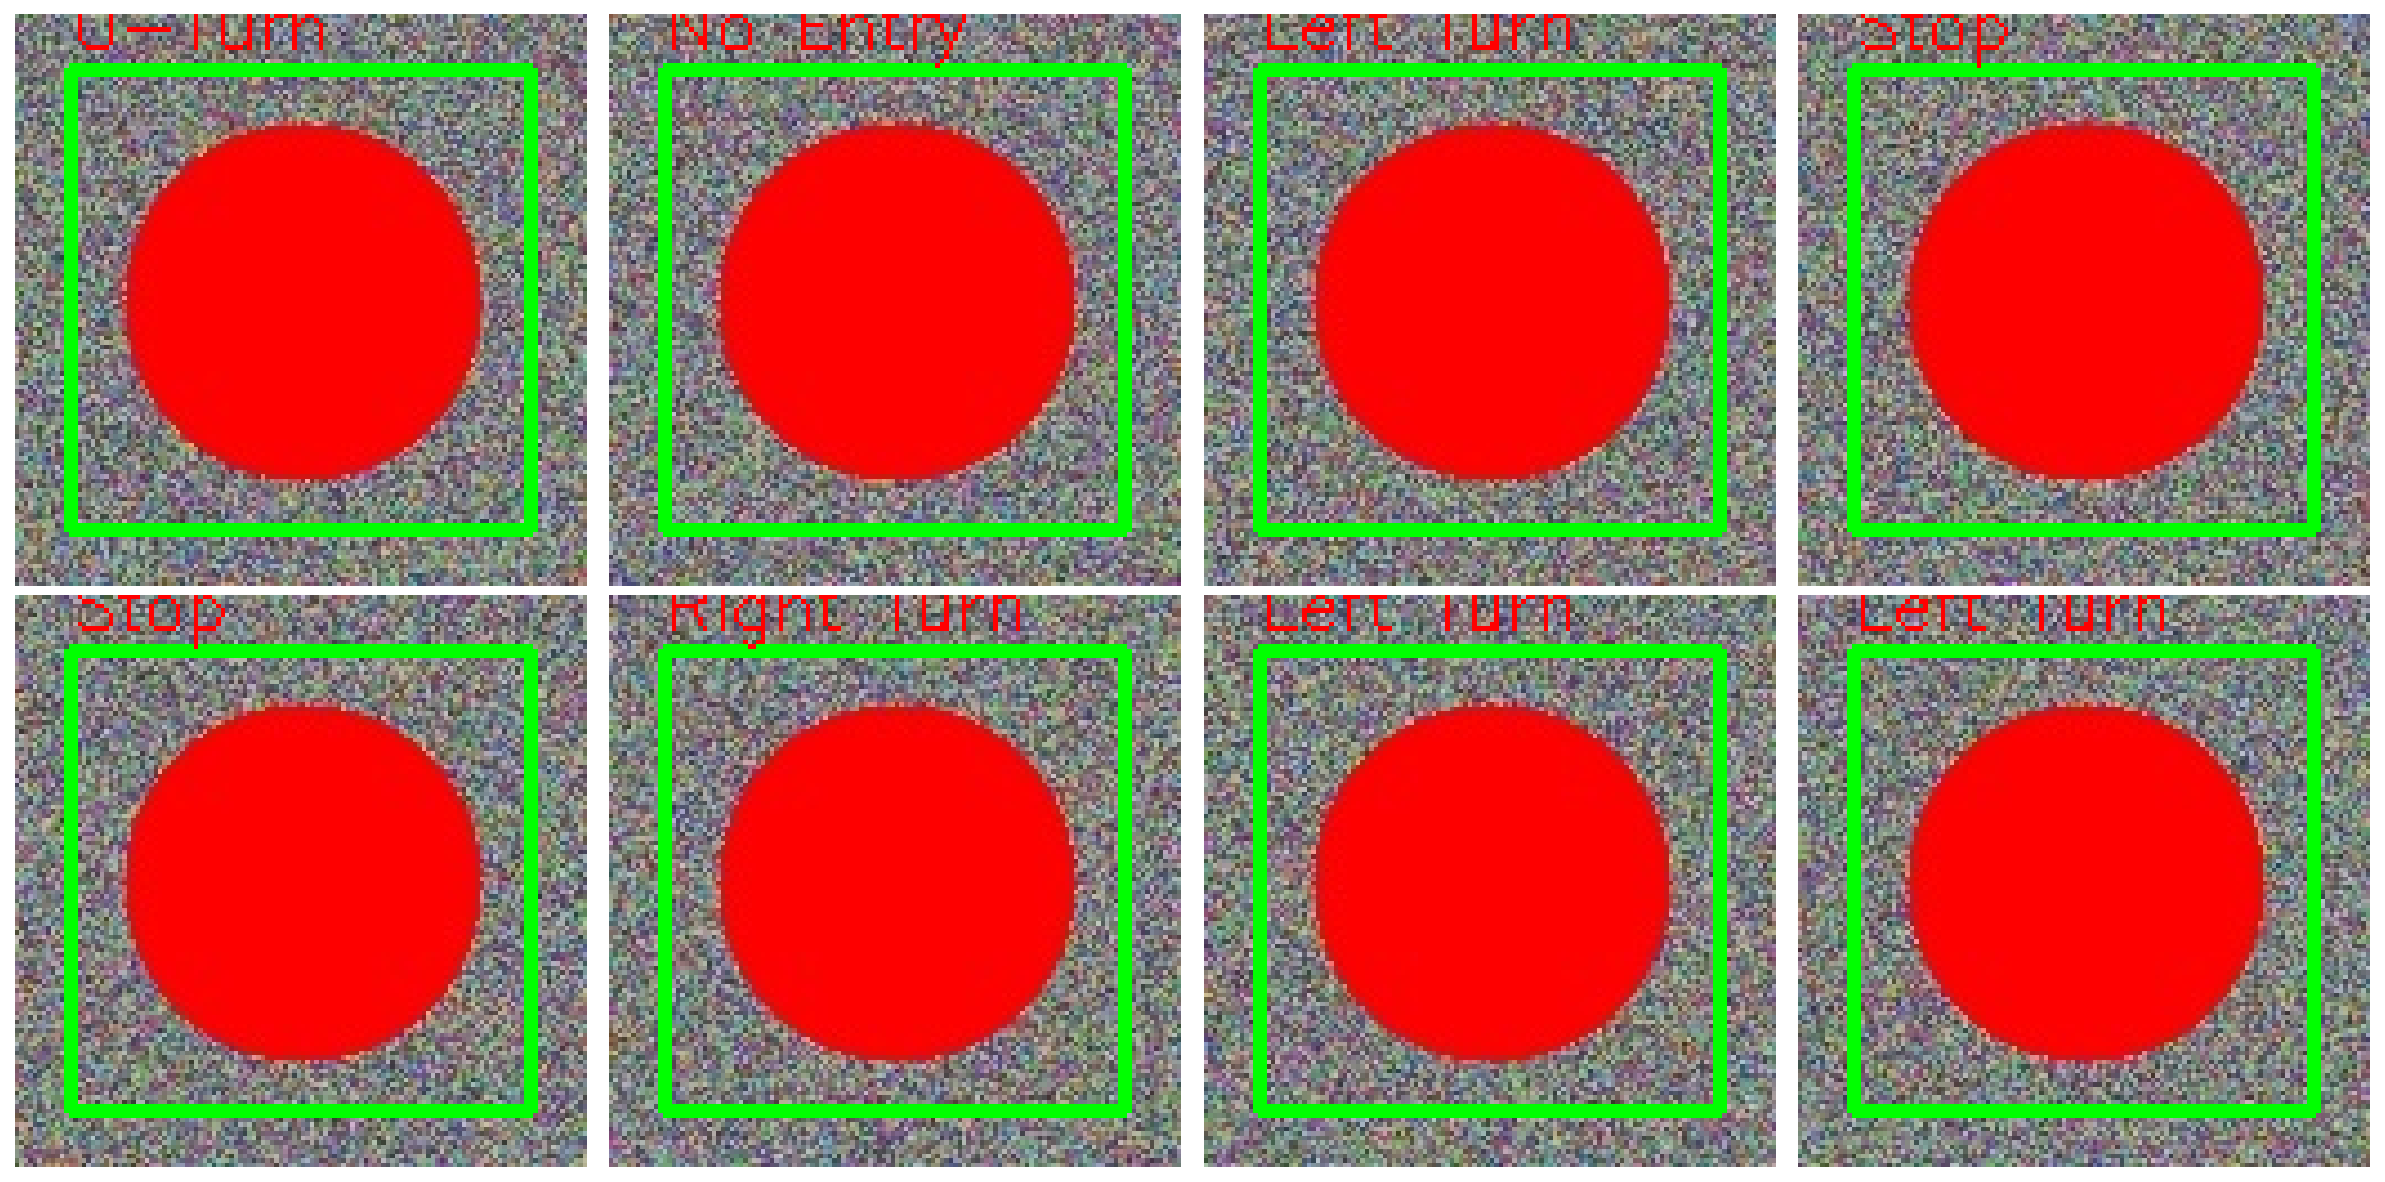

In [6]:
validator = AnnotationValidator()
for split in ['train', 'val', 'test']:
    img_dir = DATA_DIR / 'processed' / 'images' / split
    lbl_dir = DATA_DIR / 'processed' / 'labels' / split
    if img_dir.exists():
        stats = validator.verify_split(img_dir, lbl_dir)
        print(f'{split}: {stats["total_images"]} images, {stats["total_boxes"]} boxes')
        vis_path = OUTPUTS_DIR / 'reports' / f'annotations_{split}.png'
        validator.visualize_sample(img_dir, lbl_dir, vis_path, num_samples=8)

from IPython.display import Image, display
display(Image(filename=str(OUTPUTS_DIR / 'reports' / 'annotations_train.png')))

In [7]:

import sys
import importlib

# Force unload the cached benchmark module if it exists
if 'scripts.benchmark' in sys.modules:
    del sys.modules['scripts.benchmark']
if 'scripts' in sys.modules:
    del sys.modules['scripts']

# Now import again
from scripts.benchmark import benchmark_model_variants


## 4. Model Benchmark (YOLOv8 vs YOLOv11)

In [8]:
from scripts.benchmark import benchmark_model_variants

results = benchmark_model_variants(
    str(DATA_DIR / 'processed' / 'dataset.yaml'),
    OUTPUTS_DIR / 'benchmarks'
)

for name, data in results.items():
    if 'error' not in data:
        print(f'{name}: mAP50={data.get("mAP50","N/A")}, FPS={data.get("avg_fps","N/A")}, Size={data.get("size_mb","N/A")}MB')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 699.6±225.0 MB/s, size: 11.8 KB)
val: Scanning /content/ML-model-trafic-sign/data/processed/labels/val... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 1.8Kit/s 0.0s
val: New cache created: /content/ML-model-trafic-sign/data/processed/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0it/s 0.5s
                   all          6          6          0          0          0          0
Speed:

## 5. Training (YOLOv11 Nano — Transfer Learning + AMP + Early Stopping)

In [9]:
from src.training.trainer import TrafficSignTrainer

trainer = TrafficSignTrainer(
    model_weights='yolo11n.pt',
    data_yaml=str(DATA_DIR / 'processed' / 'dataset.yaml'),
    project_dir=OUTPUTS_DIR / 'training',
)

# For demo/quick run use fewer epochs; production: 150
EPOCHS = 10  # Change to 150 for full training

results = trainer.train(
    resume=False,
    epochs=EPOCHS,
    batch=16,
    imgsz=640,
    device=0,
    patience=25,
    amp=True,
    cos_lr=True,
)
print('Best weights:', results['best_weights'])

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/ML-model-trafic-sign/data/processed/dataset.yaml, degrees=15.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_sign_yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, 

In [10]:
from IPython.display import Image, display
results_img = OUTPUTS_DIR / 'training' / 'traffic_sign_yolo11n' / 'results.png'
if results_img.exists():
    display(Image(filename=str(results_img)))

## 6. Validation & Metrics

In [11]:
BEST_MODEL = str(OUTPUTS_DIR / 'training' / 'traffic_sign_yolo11n' / 'weights' / 'best.pt')

from src.evaluation.metrics import MetricsEvaluator

evaluator = MetricsEvaluator(BEST_MODEL, str(DATA_DIR / 'processed' / 'dataset.yaml'))
report = evaluator.generate_report(OUTPUTS_DIR / 'evaluation')

for split in ['val_metrics', 'test_metrics']:
    m = report[split]
    print(f'\n=== {split} ===')
    print(f'  Precision: {m["precision"]:.4f}')
    print(f'  Recall:    {m["recall"]:.4f}')
    print(f'  F1:        {m["f1"]:.4f}')
    print(f'  mAP50:     {m["mAP50"]:.4f}')
    print(f'  mAP50-95:  {m["mAP50-95"]:.4f}')

FileNotFoundError: [Errno 2] No such file or directory: '/content/ML-model-trafic-sign/outputs/training/traffic_sign_yolo11n/weights/best.pt'

## 7. Error Analysis (FP / FN / Failure Cases)

In [ ]:
from src.evaluation.error_analysis import ErrorAnalyzer

analyzer = ErrorAnalyzer(BEST_MODEL)
stats = analyzer.analyze_split(
    DATA_DIR / 'processed' / 'images' / 'test',
    DATA_DIR / 'processed' / 'labels' / 'test',
    OUTPUTS_DIR / 'testing' / 'test',
)

print(f'TP: {stats["true_positives"]}, FP: {stats["false_positives"]}, FN: {stats["false_negatives"]}')
for rec in analyzer.recommend_improvements(stats):
    print(f'  → {rec}')

## 8. Real-Time Inference

In [ ]:
from src.inference.detector import TrafficSignDetector

detector = TrafficSignDetector(BEST_MODEL, device=0)

# Test on image folder
test_img_dir = DATA_DIR / 'processed' / 'images' / 'test'
benchmark = detector.run_on_source(
    source=test_img_dir,
    display=False,
    save_json=True,
)
print(f'Avg FPS: {benchmark["avg_fps"]}, Latency: {benchmark["avg_latency_ms"]:.1f}ms')
print(f'Detections: {benchmark["total_detections"]}')

In [ ]:
# Example structured detection output
import cv2
from src.inference.output_formatter import format_detection
import json

sample_imgs = list((DATA_DIR / 'processed' / 'images' / 'test').glob('*.jpg'))[:3]
for img_path in sample_imgs:
    frame = cv2.imread(str(img_path))
    dets = detector.detect_frame(frame)
    print(f'{img_path.name}: {json.dumps(dets, indent=2)}')

## 9. Model Export (PyTorch, ONNX, TFLite)

In [ ]:
from src.export.exporter import ModelExporter

exporter = ModelExporter(BEST_MODEL, OUTPUTS_DIR / 'exports')
export_results = exporter.benchmark_formats(imgsz=640)

for fmt, data in export_results.items():
    if fmt == 'recommendation':
        continue
    if 'error' in data:
        print(f'{fmt}: ERROR - {data["error"]}')
    else:
        print(f'{fmt}: {data["size_mb"]}MB, {data["avg_inference_ms"]}ms, {data["avg_fps"]} FPS')

print('\nPi recommendation:', export_results.get('recommendation', {}).get('recommended_format'))

## 10. Download Trained Model

In [ ]:
import shutil
from google.colab import files

zip_path = '/content/traffic_sign_model_bundle.zip'
shutil.make_archive('/content/traffic_sign_model_bundle', 'zip',
                    root_dir=str(OUTPUTS_DIR))
files.download(zip_path)